In [18]:
import pandas as pd
import numpy as np

fish_fry = pd.read_csv("fish_fry_results.csv", index_col=0)
cost_of_living = pd.read_csv("affordability_results.csv")
enrollment = pd.read_csv("Enrollment_results.csv")

#Edit these later aswell
COST_OF_LIVING_WEIGHT = 0.34
FISH_FRY_WEIGHT       = 0.33
SAFETY_WEIGHT         = 0.33


final_df = pd.merge(enrollment,cost_of_living,how='left', on="Neighborhood")
#final_df = pd.merge(cost_of_living, how='right', on="Neighborhood")
#final_df = final_df.merge(enrollment[["Neighborhood", "Enrollment_score"]],how='right', on="Neighborhood")

#final_df["final_score"] = (
#    final_df["cost_of_living_score"] * COST_OF_LIVING_WEIGHT +
#    final_df["fish_fry_score"]       * FISH_FRY_WEIGHT +
#    final_df["safety_score"]         * SAFETY_WEIGHT
#)

# Sort and display
#final_results = final_df[["Neighborhood", "cost_of_living_score", "fish_fry_score", "safety_score", "final_score"]].sort_values("final_score", ascending=False)

In [22]:
final_df['total_score'] = final_df['Enrollment_Score']+final_df['cost_of_living_score']
final_df=final_df.sort_values(by='total_score', ascending=False)
final_df=final_df.dropna()

In [12]:
ManualScores = pd.read_csv("Total score with fish frys included.csv")

ManualScores=ManualScores.nlargest(20, 'Total Score after')

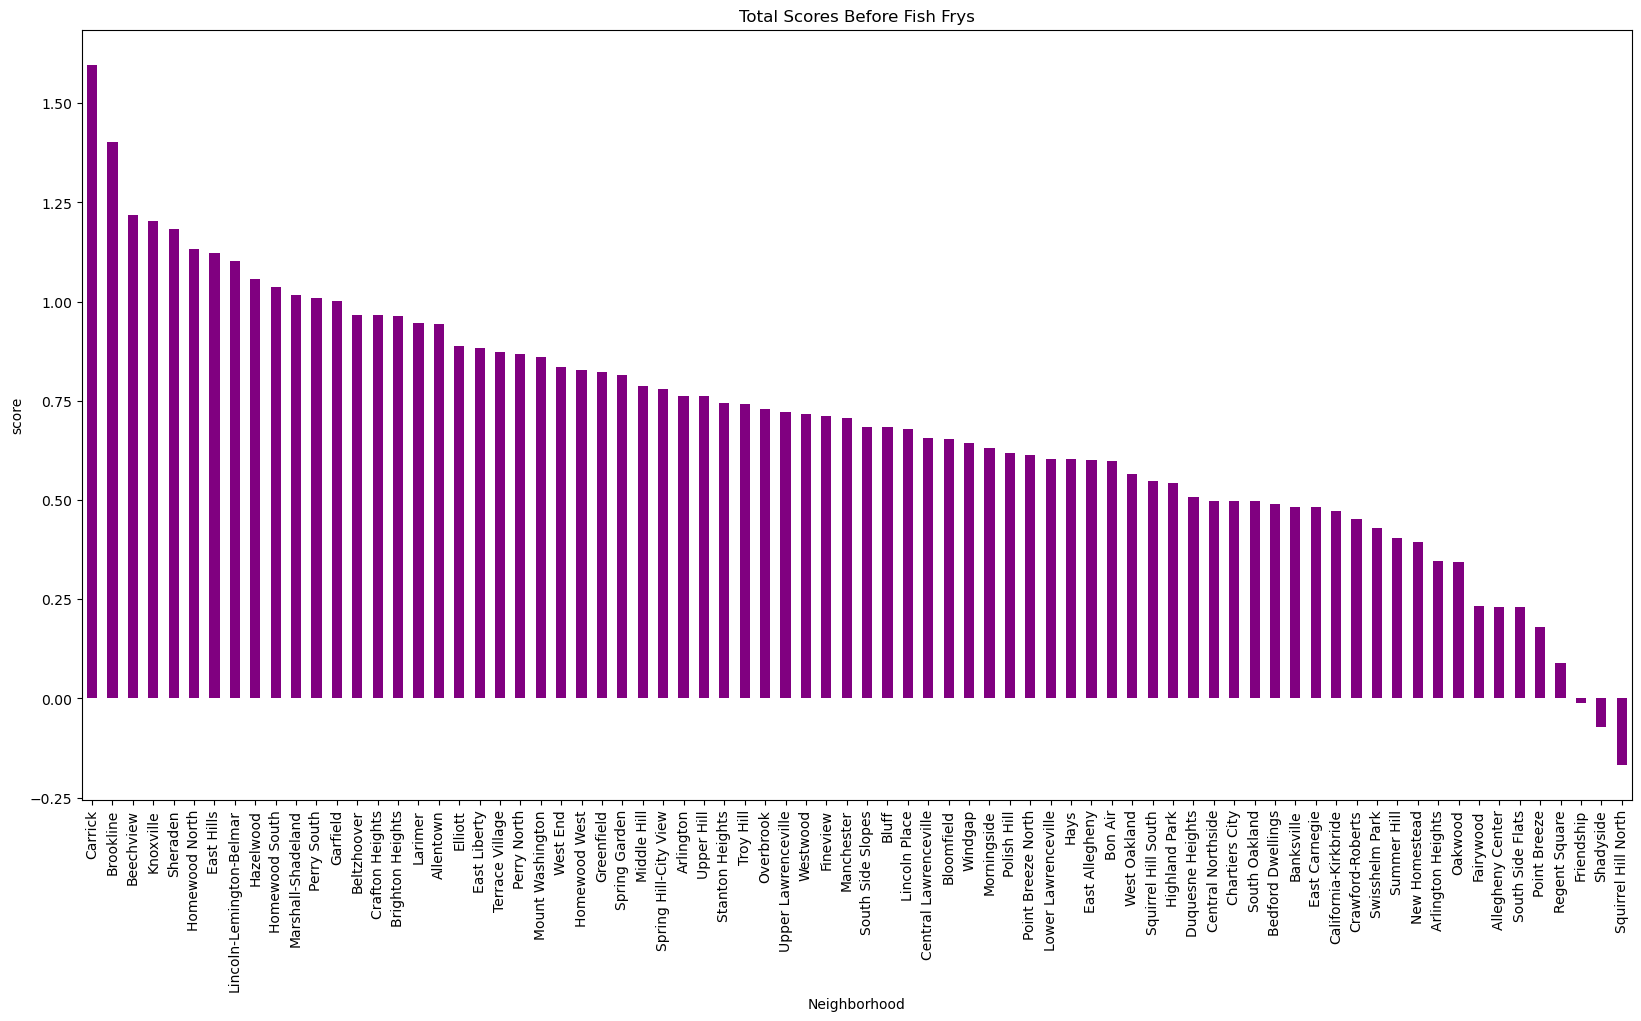

In [24]:
BeforeFish = final_df.plot.bar(x='Neighborhood',y='total_score',title='Total Scores Before Fish Frys',xlabel='Neighborhood',ylabel='score',figsize=(20,10),legend=False,color='purple')

*Note: Fish frys not reflected due to data not meshing well with this data but can be referenced manually to derive results scores*

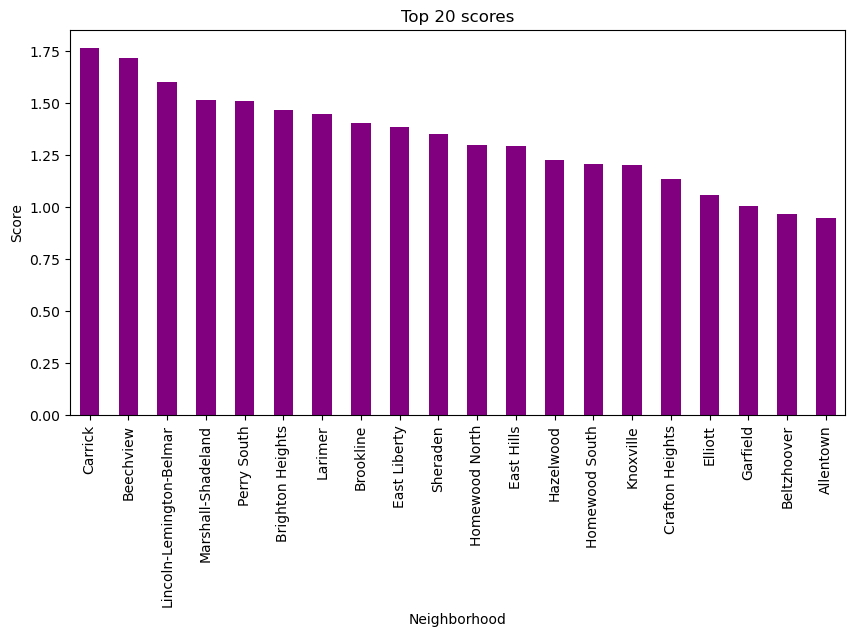

In [25]:
AfterFish = ManualScores.plot.bar(x='Neighborhood',y='Total Score after',title='Top 20 scores',xlabel='Neighborhood',ylabel='Score',figsize=(10,5),legend=False,color='purple')

*Note: Created separate csv and manually entered fish fry score to the top 20 neighborhoods from above*

## Cost of Living Score

### Process
- Selected cost of living because it is the most essential metric for evaluating neighborhoods
- Comprehensive data was difficult to find, with government census data being the most reliable source
- Two metrics required proxies due to data limitations:
    - **Transportation Cost** → Percent of residents who commute by car
    - **Rent Burden** → Median home value divided by median income
- A small number of neighborhoods had missing data, though none would have impacted the final ranking

---

### Missing Data

| Neighborhood | Missing Field | Estimated Value |
|---|---|---|
| Allegheny Center | Median Sale Price | ~$125,000 |
| Arlington Heights | Median Sale Price | ~$100,000 |
| Glen Hazel | Median Sale Price | ~$114,350 (midpoint of $83,700–$145,000 range) |
| North Shore | Median Home Value | $111,755 |
| South Shore | Median Home Value | ~$125,000 |
| Northview Heights | Median Home Value | $130,000 |
| Chateau | Multiple Fields | Not scored — sparse population and insufficient data |

---

### Affordability Rankings

<img src="affordability_rankings.png" width="600">

### Conclusion

TODO

Aaron V:
Carrick, based on raw numbers, seems to be the the best place to live. Enrollment is high, the cost of living is cheap and there are **TWO** fish frys located within the neighborhood. Has everything you could want! Although if it were up to me Id pick Beechview or Lincoln-Lemington-Belmar as they have **double** the amount of fish frys with only a moderate hit to the other scores. Ultimately the big deciding factor here is waht you value most, the Top 20 options all are within a small enough margin that you can be picky about what you want to prioritize. *You should be lookin at those fish fry metrics...*

Rohan: Carrick makes sense as the best neighboorhood, especially given we used cost of living as one of our factors. My personal choice of best neighboorhood is Shadyside but it is very expensive. Overall the data pretty accurately reflects the actual quality of the neighborhoods and could be used to draw useful conclusions. 